## Title - Exploratory Analysis of IMDb Movies: Trends in Ratings, Revenue, and Audience Preferences

### Name - Saikumar Lakkaram
### Subject - M512B Data Visualisation and Communication
### ID - GH1047507

#### Dataset Link - https://www.kaggle.com/datasets/akashkotal/imbd-top-1000-with-description
#### Source Link - https://www.imdb.com/search/title/?num_votes=10000,&sort=user_rating,desc&title_type=feature
#### GitHub Link - https://github.com/saikumarlakkaram/Top-1000-IMDb-Rated-Movies-/blob/main/Data_visualization_IMDb.ipynb

# Business Problem
The objective of this project is to analyze the Top 1000 IMDb movies dataset to extract meaningful insights about movie ratings, popularity, runtime, and revenue.
This analysis is intended for movie production companies and streaming platforms to understand trends in highly rated movies and audience preferences.

The dataset contains information about movie titles, release years, ratings, votes, runtime, and gross revenue.

## Importing Libraries

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Loading Dataset

In [25]:
df=pd.read_csv(r"D:\SAI project\Top 1000 IMDB movies (1).csv")

In [26]:
df.head()

,Unnamed: 0,Movie Name,Year of Release,Watch Time,Movie Rating,Meatscore of movie,Votes,Gross,Description
0,0,The Shawshank Redemption,(1994),142 min,9.3,81,"34,709",$28.34M,Two imprisoned men bond over a number of years...
1,1,The Godfather,(1972),175 min,9.2,100,"34,709",$134.97M,The aging patriarch of an organized crime dyna...
2,2,The Dark Knight,(2008),152 min,9.0,84,"34,709",$534.86M,When the menace known as the Joker wreaks havo...
3,3,The Lord of the Rings: The Return of the King,(2003),201 min,9.0,94,"34,709",$377.85M,Gandalf and Aragorn lead the World of Men agai...
4,4,Schindler's List,(1993),195 min,9.0,94,"34,709",$96.90M,"In German-occupied Poland during World War II,..."


In [27]:
df=df.drop(columns=['Unnamed: 0'])

In [28]:
df

,Movie Name,Year of Release,Watch Time,Movie Rating,Meatscore of movie,Votes,Gross,Description
0,The Shawshank Redemption,(1994),142 min,9.3,81,"34,709",$28.34M,Two imprisoned men bond over a number of years...
1,The Godfather,(1972),175 min,9.2,100,"34,709",$134.97M,The aging patriarch of an organized crime dyna...
2,The Dark Knight,(2008),152 min,9.0,84,"34,709",$534.86M,When the menace known as the Joker wreaks havo...
3,The Lord of the Rings: The Return of the King,(2003),201 min,9.0,94,"34,709",$377.85M,Gandalf and Aragorn lead the World of Men agai...
4,Schindler's List,(1993),195 min,9.0,94,"34,709",$96.90M,"In German-occupied Poland during World War II,..."
...,...,...,...,...,...,...,...,...
995,Sabrina,(1954),113 min,7.6,72,"34,709",%^%^%^,A playboy becomes interested in the daughter o...
996,From Here to Eternity,(1953),118 min,7.6,85,"34,709",$30.50M,"At a U.S. Army base in 1941 Hawaii, a private ..."
997,Snow White and the Seven Dwarfs,(1937),83 min,7.6,95,"34,709",$184.93M,Exiled into the dangerous forest by her wicked...
998,The 39 Steps,(1935),86 min,7.6,93,"34,709",%^%^%^,A man in London tries to help a counter-espion...


## Data Exploration

In [29]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Movie Name          1000 non-null   object 
 1   Year of Release     1000 non-null   object 
 2   Watch Time          1000 non-null   object 
 3   Movie Rating        1000 non-null   float64
 4   Meatscore of movie  1000 non-null   object 
 5   Votes               1000 non-null   object 
 6   Gross               1000 non-null   object 
 7   Description         1000 non-null   object 
dtypes: float64(1), object(7)
memory usage: 62.6+ KB


,Movie Rating
count,1000.000000
mean,7.962700
std,0.276759
min,7.600000
25%,7.700000
50%,7.900000
75%,8.100000
max,9.300000


## Missing Values

In [30]:
df.isnull().sum()

Movie Name            0
Year of Release       0
Watch Time            0
Movie Rating          0
Meatscore of movie    0
Votes                 0
Gross                 0
Description           0
dtype: int64

In [31]:
df = df.dropna()

In [32]:
df

,Movie Name,Year of Release,Watch Time,Movie Rating,Meatscore of movie,Votes,Gross,Description
0,The Shawshank Redemption,(1994),142 min,9.3,81,"34,709",$28.34M,Two imprisoned men bond over a number of years...
1,The Godfather,(1972),175 min,9.2,100,"34,709",$134.97M,The aging patriarch of an organized crime dyna...
2,The Dark Knight,(2008),152 min,9.0,84,"34,709",$534.86M,When the menace known as the Joker wreaks havo...
3,The Lord of the Rings: The Return of the King,(2003),201 min,9.0,94,"34,709",$377.85M,Gandalf and Aragorn lead the World of Men agai...
4,Schindler's List,(1993),195 min,9.0,94,"34,709",$96.90M,"In German-occupied Poland during World War II,..."
...,...,...,...,...,...,...,...,...
995,Sabrina,(1954),113 min,7.6,72,"34,709",%^%^%^,A playboy becomes interested in the daughter o...
996,From Here to Eternity,(1953),118 min,7.6,85,"34,709",$30.50M,"At a U.S. Army base in 1941 Hawaii, a private ..."
997,Snow White and the Seven Dwarfs,(1937),83 min,7.6,95,"34,709",$184.93M,Exiled into the dangerous forest by her wicked...
998,The 39 Steps,(1935),86 min,7.6,93,"34,709",%^%^%^,A man in London tries to help a counter-espion...


In [33]:
df.duplicated().sum()

np.int64(0)

# Insight 1 - Rating Distribution

# What is the overall distribution of movie ratings?

In [34]:
mean_rating = df["Movie Rating"].mean()
print(mean_rating)

7.9627


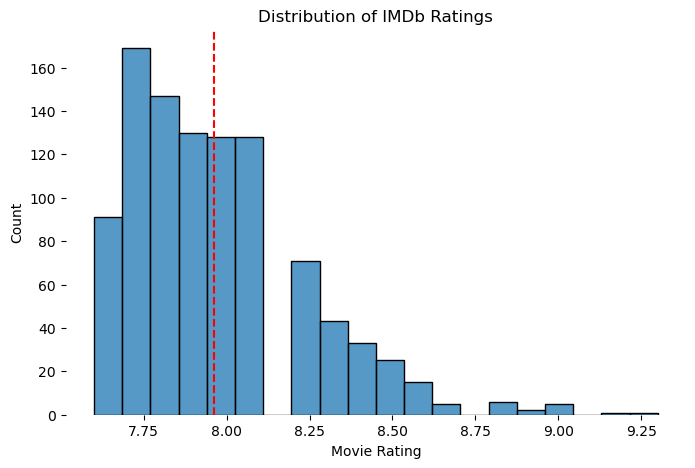

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Movie Rating"], bins=20)
mean_rating = df["Movie Rating"].mean()
plt.axvline(mean_rating, color='red', linestyle='dashed')
plt.title("Distribution of IMDb Ratings")
plt.box(False)
plt.show()

Most movies have ratings between 7.5 and 8.5, with an average rating of around 7.96

The histogram clearly shows that movie ratings are heavily concentrated in a narrow range, mainly between 7.5 and 8.5. This indicates that most movies in the dataset maintain a consistent level of quality, without extreme variations. The presence of fewer movies at very high ratings (above 9.0) suggests that exceptional films are rare.

The dashed red line representing the average rating lies near the center of the distribution, confirming that the ratings are fairly balanced and not skewed heavily in one direction. This also indicates that the dataset does not contain many poorly rated movies, as most films meet a certain quality standard.

Overall, this pattern suggests that the film industry produces a large number of moderately high-quality movies, while only a small number achieve outstanding success in terms of ratings

# Insight 2 — IMDb Rating vs Metascore Comparison

# How do audience ratings (IMDb) compare with critics’ scores (Metascore) for top-rated movies?

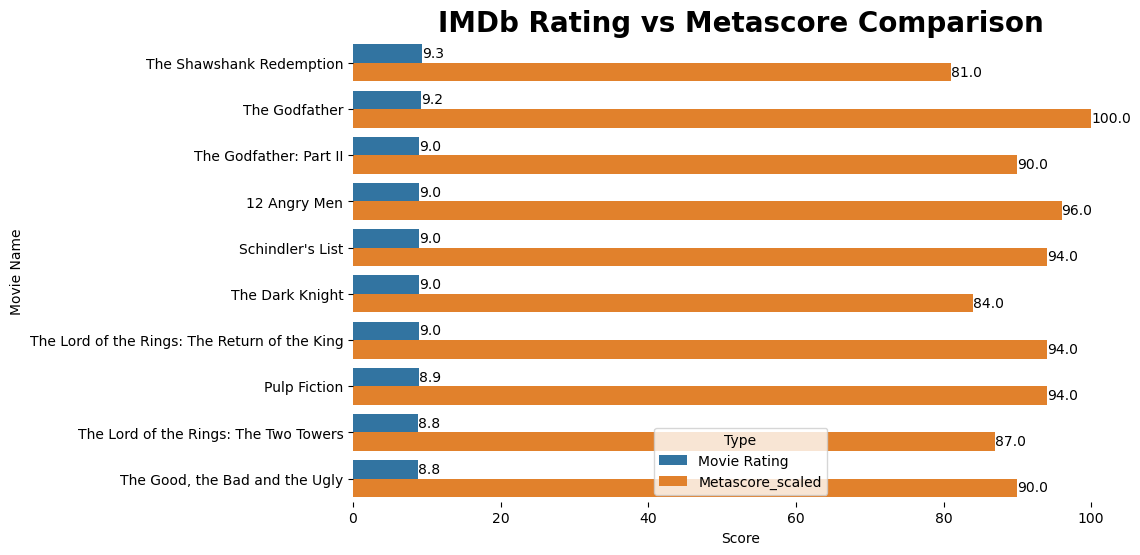

In [37]:

df["Meatscore of movie"] = pd.to_numeric(df["Meatscore of movie"], errors='coerce')

df_clean = df.dropna(subset=["Movie Rating", "Meatscore of movie", "Movie Name"])

top_movies = df_clean.sort_values(by="Movie Rating", ascending=False).head(10)

top_movies["Metascore_scaled"] = top_movies["Meatscore of movie"] / 1

plot_data = top_movies.melt(
    id_vars="Movie Name",
    value_vars=["Movie Rating", "Metascore_scaled"],
    var_name="Type",
    value_name="Score"
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_data,
    x="Score",
    y="Movie Name",
    hue="Type"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.title("IMDb Rating vs Metascore Comparison",fontsize=20,fontweight='bold')
plt.box(False)
plt.show()

Top-rated movies generally have high scores from both audiences and critics, but critics’ scores (Metascore) tend to vary more, while IMDb ratings remain consistently high.

The bar chart compares audience ratings (IMDb) with critics’ scores (Metascore) for the top 10 highest-rated movies. It is clear that these movies receive strong appreciation from both audiences and critics, indicating their overall high quality.

However, a closer look reveals that IMDb ratings are tightly clustered within a narrow range (around 8.8 to 9.3), showing that audiences consistently rate these top movies highly. In contrast, Metascore values vary more widely, ranging from the low 80s to 100. This suggests that critics tend to differentiate more between movies, applying stricter evaluation criteria.

This difference highlights that while audiences generally agree on top-performing movies, critics provide more varied and detailed assessments. Despite these variations, the overall agreement between both groups indicates that these movies are widely recognized as high-quality films

# Insight 3 — Top Movies: Year vs Rating Trend

# How are the highest-rated movies distributed over time, and is there any trend in their ratings across years?

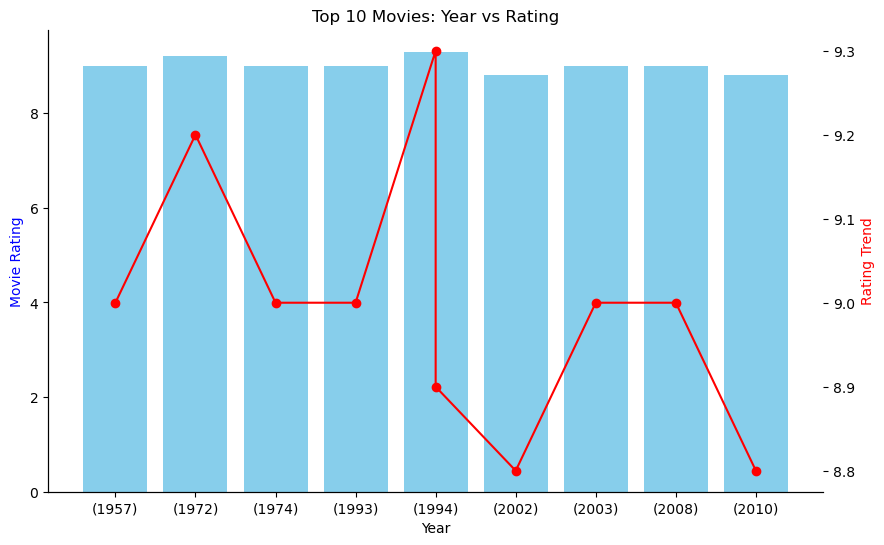

In [38]:

top_movies = df.sort_values(by="Movie Rating", ascending=False).head(10)

top_movies = top_movies.sort_values(by="Year of Release")

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(
    top_movies["Year of Release"],
    top_movies["Movie Rating"],
    color="skyblue"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Movie Rating", color="blue")

ax2 = ax1.twinx()
ax2.plot(
    top_movies["Year of Release"],
    top_movies["Movie Rating"],
    color="red",
    marker="o"
)
ax2.set_ylabel("Rating Trend", color="red")
sns.despine()

plt.title("Top 10 Movies: Year vs Rating")

plt.show()

Top-rated movies are spread across different years, and their ratings remain consistently high (around 8.8–9.3) with no strong upward or downward trend.
The chart displays the top 10 highest-rated movies along with their release years and corresponding ratings. It shows that these top-performing movies are not concentrated in a single time period but are distributed across several decades, from older classics to more recent films.

The bar chart indicates that all selected movies have very high ratings, while the line plot highlights the slight variation in ratings across years. However, these variations are minimal, as most ratings fall within a narrow range between 8.8 and 9.3.

This suggests that exceptional movies are produced across different time periods, and there is no specific era that dominates in terms of quality. The consistency in ratings also indicates that audience appreciation for top-quality films remains stable over time, regardless of when the movie was released.

# Insight 4 — Top 10 Highest Grossing Movies

# Which movies generate the highest revenue, and how is revenue distributed among top-performing films?

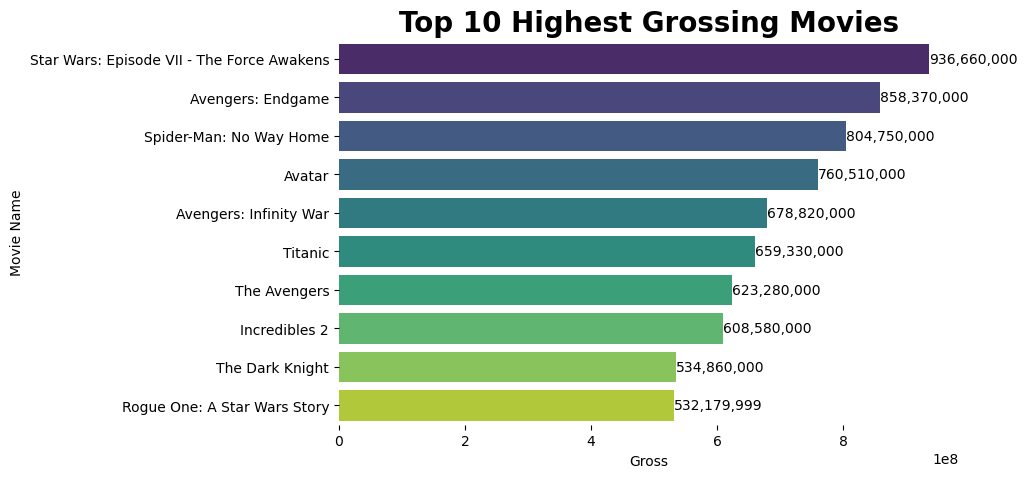

In [39]:

top_gross = df.sort_values(by="Gross", ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_gross,
    x="Gross",
    y="Movie Name",
    palette="viridis"
)

for i, v in enumerate(top_gross["Gross"]):
    plt.text(v, i, f"{int(v):,}", va='center')

plt.title("Top 10 Highest Grossing Movies",fontsize=20,fontweight='bold')
plt.box(False)
plt.show()


A small number of movies generate extremely high revenue, with top films earning significantly more than others, indicating a strong concentration of earnings among blockbuster movies

The bar chart presents the top 10 highest-grossing movies, clearly showing a significant gap between the top performers and the rest. Movies like Star Wars: The Force Awakens and Avengers: Endgame stand out with exceptionally high revenue compared to others in the list.

The distribution of revenue is not uniform, as a few blockbuster movies dominate the total earnings. This highlights the “hit-driven” nature of the film industry, where a small number of successful films contribute a large share of overall revenue.

Additionally, many of the top-grossing movies belong to popular franchises such as Marvel and Star Wars, indicating that established brands and sequels tend to perform better commercially. This suggests that audience familiarity and strong fan bases play a crucial role in driving revenue.

# Insight 5— Movie Rating vs Gross Revenue

# Is there a relationship between movie ratings and gross revenue? Do higher-rated movies always earn more?

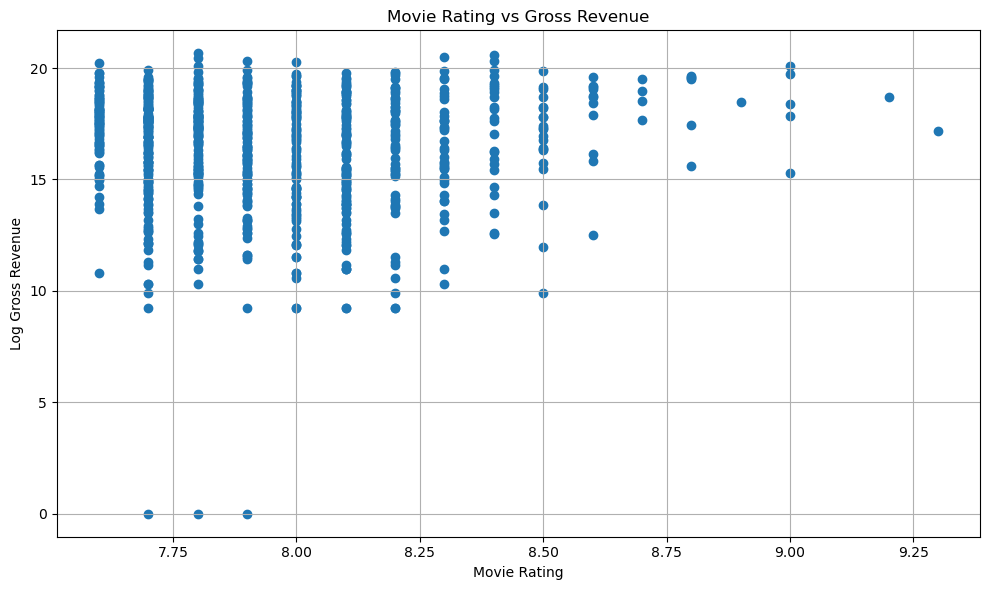

In [40]:
import matplotlib.pyplot as plt

df["Gross_log"] = np.log1p(df["Gross"])

plt.figure(figsize=(10,6))

plt.scatter(
    df["Movie Rating"],
    df["Gross_log"]
)

plt.title("Movie Rating vs Gross Revenue")
plt.xlabel("Movie Rating")
plt.ylabel("Log Gross Revenue")

plt.grid(True)

plt.tight_layout()
plt.show()

There is no strong direct relationship between ratings and revenue. High-rated movies do not always generate the highest revenue, and some moderately rated movies achieve high earnings.

The scatter plot shows the relationship between movie ratings and gross revenue (log scale). While it might be expected that higher-rated movies earn more revenue, the chart reveals that this is not always the case.

Movies with ratings between 7.5 and 8.5 are spread across a wide range of revenue values, indicating that movies with similar quality can perform very differently at the box office. Some movies with average ratings generate very high revenue, while some highly rated movies earn comparatively less.

This suggests that factors such as marketing, franchise popularity, release timing, and audience reach play a more significant role in determining revenue than ratings alone. Therefore, commercial success is influenced by multiple factors beyond just movie quality.

# Insight 6 — Revenue Distribution by Movie Length

# How does movie runtime (short, medium, long) affect revenue generation?

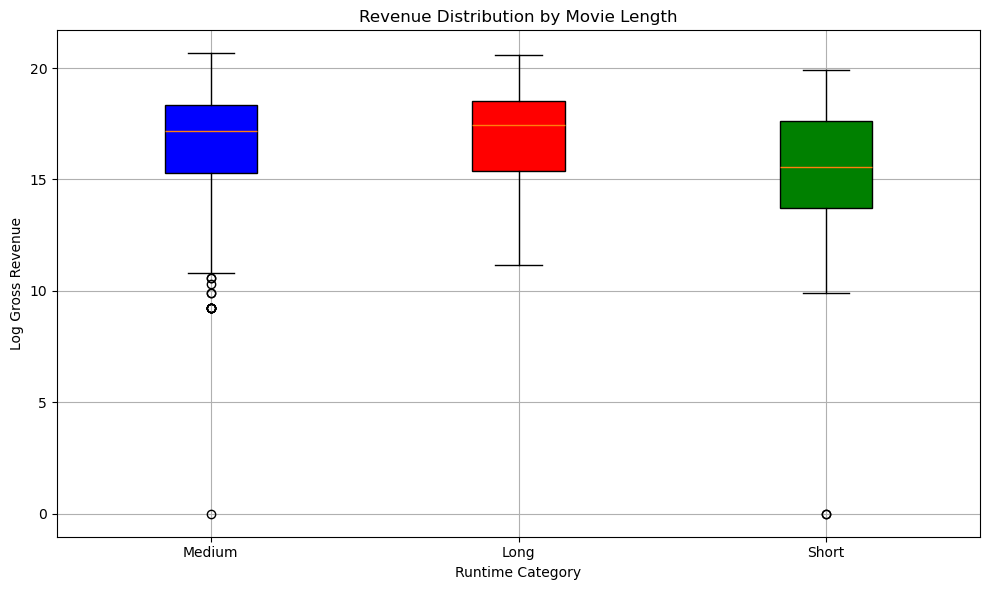

In [41]:
import matplotlib.pyplot as plt
import numpy as np

df["watch_time_min"] = df["Watch Time"].str.extract(r"(\d+)").astype(float)

df["runtime_category"] = pd.cut(
    df["watch_time_min"],
    bins=[0, 100, 150, 300],
    labels=["Short", "Medium", "Long"]
)

df["Gross_log"] = np.log1p(df["Gross"])

df_clean = df.dropna(subset=["runtime_category", "Gross_log"])

short = df_clean[df_clean["runtime_category"] == "Short"]["Gross_log"]
medium = df_clean[df_clean["runtime_category"] == "Medium"]["Gross_log"]
long = df_clean[df_clean["runtime_category"] == "Long"]["Gross_log"]

plt.figure(figsize=(10,6))

box = plt.boxplot(
    [medium, long, short],
    labels=["Medium", "Long", "Short"],
    patch_artist=True
)

colors = ["blue", "red", "green"]
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title("Revenue Distribution by Movie Length")
plt.xlabel("Runtime Category")
plt.ylabel("Log Gross Revenue")

plt.grid(True)
plt.tight_layout()

plt.show()

Medium and long movies tend to generate higher and more consistent revenue, while short movies generally show lower and more varied performance.

The box plot compares revenue distribution across three runtime categories: short, medium, and long movies. It shows that medium-length movies have a relatively stable and higher median revenue, indicating consistent performance at the box office.

Long movies also demonstrate strong revenue potential, with some high-performing outliers, suggesting that longer films can achieve significant success, possibly due to epic storytelling or franchise appeal. However, they also show slightly more variation, indicating higher risk.

On the other hand, short movies generally have lower median revenue and a wider spread, indicating inconsistent performance. This suggests that shorter films may not always attract large audiences or generate high earnings.

Overall, the analysis indicates that movie length plays a role in revenue generation, with medium-length movies offering a balance between consistency and performance, while longer movies carry both high reward and variability.

# Recommandetions

1.Focus on Consistent Quality

2.Do Not Rely Only on Ratings for Revenue

3.Leverage Popular Franchises and Branding

4.Optimize Movie Length

5.Balance Critics and Audience Expectations

6.Plan Release Timing Strategically

7.Use Data-Driven Decision Making


# Conclusion

The analysis of the Top 1000 IMDb movies dataset reveals several important insights about movie performance and audience behavior. Most movies maintain consistent ratings, indicating a stable level of quality across the industry. However, revenue generation is highly uneven, with a small number of blockbuster movies contributing significantly to total earnings.

The relationship between ratings and revenue is not strongly correlated, showing that high-quality movies do not always achieve high commercial success. Other factors such as popularity, marketing, and franchise value play a crucial role in driving revenue.

Additionally, movie length has a noticeable impact on performance, with medium-length movies showing consistent results and longer movies offering higher potential but greater variability. The comparison between critics and audience ratings highlights that while both generally agree on top movies, critics tend to evaluate films more strictly.

Overall, the findings suggest that success in the movie industry depends on a combination of quality, audience engagement, and strategic factors rather than any single metric. These insights can help production companies and streaming platforms make better decisions regarding content creation, promotion, and investment.